# Benchmark Selection Statistics

Plots and tables for the benchmark-selection report, computed from `selected_benchmarks.csv`
(the final set of 400 instances), `benchmarks2026.csv` (the submission pool the script drew from), and `benchmarks2026-with-minisat1m-yes.csv` (the submission pool including the too-easy instances).


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Final selection, the submission pool the script drew from, and the full submission pool incl. too-easy
sel = pd.read_csv('selected_benchmarks.csv')
sub = pd.read_csv('benchmarks2026.csv', sep=r'\s+')
sub_all = pd.read_csv('benchmarks2026-with-minisat1m-yes.csv', sep=r'\s+')

print(f"selected:       {len(sel)} rows, {sel['isohash2'].nunique()} distinct (IsoHash2)")
print(f"submitted ms>1: {len(sub)} rows, {sub['isohash2'].nunique()} distinct (IsoHash2)")
print(f"submitted all:  {len(sub_all)} rows (incl. {(sub_all['minisat1m'] == 'yes').sum()} too-easy)")


selected:       400 rows, 400 distinct (IsoHash2)
submitted ms>1: 1028 rows, 994 distinct (IsoHash2)
submitted all:  1096 rows (incl. 68 too-easy)


## Histograms

Distribution of the selected instances across families and authors. Groups of size less than five are aggregated into `misc` buckets.


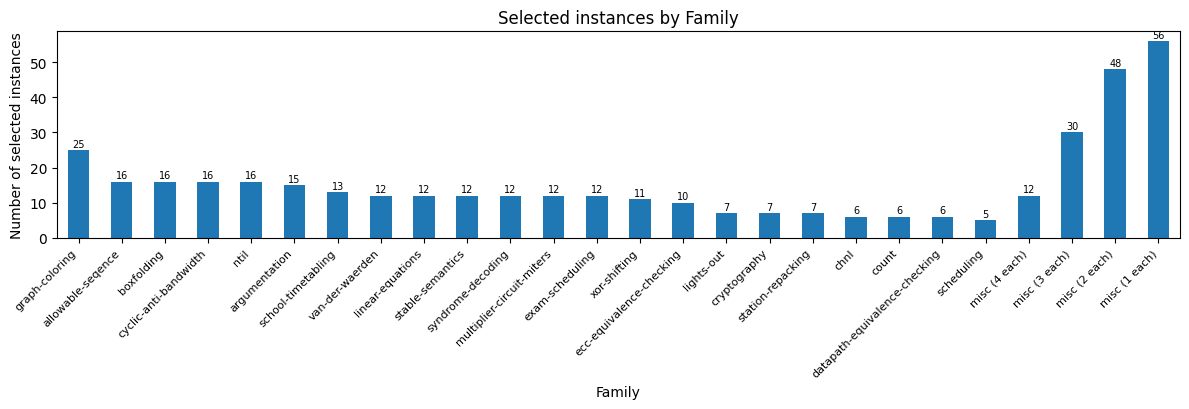

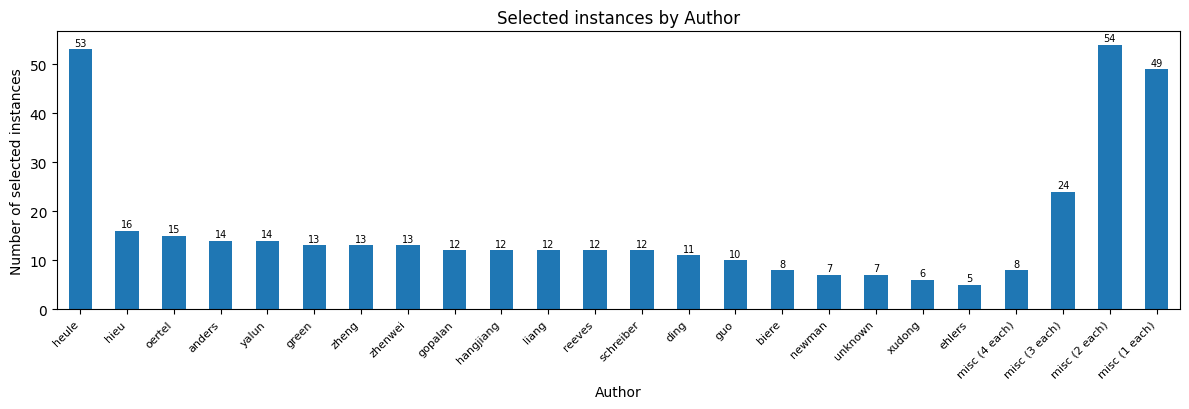

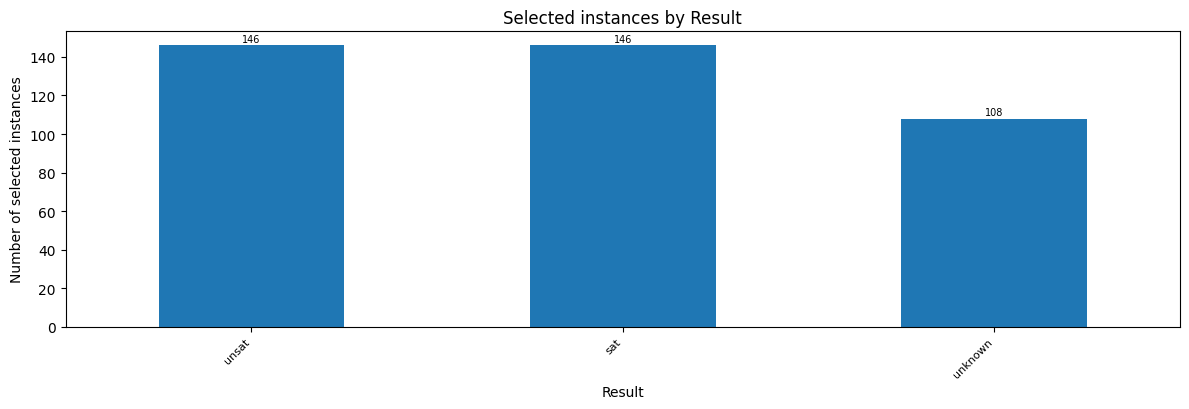

In [14]:
def plot_hist(col, threshold=4, fname=None):
    counts = sel[col].value_counts()
    bars = counts[counts > threshold].copy()
    # aggregate the long tail into one bucket per group size
    for k in range(threshold, 0, -1):
        instances_k = int(counts[counts == k].sum())
        if instances_k > 0:
            bars[f'misc ({k} each)'] = instances_k

    ax = bars.plot(kind='bar', figsize=(12, 4.2))
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Number of selected instances')
    ax.set_title(f'Selected instances by {col.capitalize()}')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    for i, v in enumerate(bars.values):
        ax.annotate(str(int(v)), (i, v), ha='center', va='bottom',
                    fontsize=7, xytext=(0, 1), textcoords='offset points')
    plt.tight_layout()
    if fname:
        plt.savefig(f'document/{fname}', bbox_inches='tight')
    plt.show()

plot_hist('family', fname='hist_family.pdf')
plot_hist('author', fname='hist_author.pdf')
plot_hist('result')


## Submissions per Author

Per-author funnel from submitted to selected instances: submitted incl. too-easy (`Sub.`), remaining
after excluding instances Minisat solves within a minute (`ms>1`), structurally unique after IsoHash2
deduplication (`Iso.`), and selected (`Sel.`). Participants are capped at 12 selected instances each;
benchmark-only submissions at 16 per family.


In [20]:
submitted = sub_all.groupby('author').size()   # incl. minisat1m=yes (too-easy)
grp = sub.groupby('author')                    # minisat-filtered pool (ms>1)
submissions = pd.DataFrame({
    'Domain': grp['family'].agg(lambda s: ', '.join(sorted(s.unique()))),
    'Sub.': submitted,
    'ms>1': grp.size(),
    'Iso.': grp['isohash2'].nunique(),
    'participates': grp['participates'].first(),
})
new = sub[sub['hash'].isin(sel['hash'])]
submissions['Sel.'] = new.groupby('author').size()
cols = ['Sub.', 'ms>1', 'Iso.', 'Sel.']
submissions[cols] = submissions[cols].fillna(0).astype(int)

# Participants first, descending by Iso., benchmark-only submitters last
submissions = submissions.sort_values(['participates', 'Iso.'], ascending=[False, False]).drop(columns='participates')

total = pd.DataFrame([['', *submissions[cols].sum()]], index=['Total'], columns=['Domain', *cols])
submissions = pd.concat([submissions, total])[['Domain', *cols]]
print(submissions.to_latex())
submissions


\begin{tabular}{llrrrr}
\toprule
 & Domain & Sub. & ms>1 & Iso. & Sel. \\
\midrule
zhenwei & hard-cep, xor-shifting & 620 & 620 & 609 & 12 \\
liang & syndrome-decoding & 26 & 23 & 23 & 12 \\
anders & graph-coloring & 20 & 20 & 20 & 12 \\
green & linear-equations & 20 & 20 & 20 & 12 \\
oertel & chnl, count & 20 & 20 & 20 & 12 \\
reeves & graph-coloring & 20 & 20 & 20 & 12 \\
schreiber & school-timetabling & 20 & 20 & 20 & 12 \\
yalun & multiplier-circuit-miters & 20 & 20 & 20 & 12 \\
zheng & exam-scheduling & 20 & 20 & 20 & 12 \\
gopalan & van-der-waerden & 20 & 18 & 18 & 12 \\
hangjiang & stable-semantics & 20 & 12 & 12 & 12 \\
ding & argumentation & 20 & 11 & 11 & 11 \\
guo & ecc-equivalence-checking & 20 & 10 & 10 & 10 \\
biere & lights-out & 20 & 20 & 7 & 7 \\
faraja & graph-coloring & 20 & 1 & 1 & 1 \\
hieu & cyclic-anti-bandwidth & 104 & 101 & 101 & 16 \\
heule & allowable-seqence, boxfolding, ntil & 54 & 54 & 54 & 48 \\
xudong & datapath-equivalence-checking & 16 & 16 & 6 & 6 \\


,Domain,Sub.,ms>1,Iso.,Sel.
zhenwei,"hard-cep, xor-shifting",620,620,609,12
liang,syndrome-decoding,26,23,23,12
anders,graph-coloring,20,20,20,12
green,linear-equations,20,20,20,12
oertel,"chnl, count",20,20,20,12
reeves,graph-coloring,20,20,20,12
schreiber,school-timetabling,20,20,20,12
yalun,multiplier-circuit-miters,20,20,20,12
zheng,exam-scheduling,20,20,20,12
gopalan,van-der-waerden,20,18,18,12
